# Chapter 06 — Model Refinement & Selection

This chapter builds on the two most promising candidate models identified in Chapter 05 and focuses on refining these models to improve performance on the imbalanced stroke classification problem.

The candidate models are:

1. Logistic Regression with class weighting
2. XGBoost with class imbalance handling

The models are evaluated using stratified cross-validation and hyperparameter tuning to determine whether systematic parameter optimization can improve model performance while maintaining appropriate handling of the highly imbalanced stroke outcome.

The refined models will subsequently be compared using recall, precision, F1-score, ROC-AUC, and Precision-Recall performance.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [20]:
# load the data
data_path = "../data/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(data_path)
df = df.drop(columns="id")
df = df[df["gender"] != "Other"]

# split the data into features and target
X = df.drop(columns=['stroke'])
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# define the preprocessing pipelines for numeric and categorical features
numeric_features = ["age", "avg_glucose_level", "bmi"]
categorical_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
binary_features = ["hypertension", "heart_disease"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

In [21]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Use the StratifiedKFold is because the positive class of stroke data is only about 5%.

Regular K-fold could produce folds with slightly different class distributions.

Stratification maintains approximately the same stroke/non-stroke ratio in every fold.

In [22]:
# logistic regression model with class_weight="balanced"
balanced_logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

lr_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}

lr_grid = GridSearchCV(
    estimator=balanced_logistic_model,
    param_grid=lr_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

lr_grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this speci

In [23]:
print("Best parameters:")
print(lr_grid.best_params_)

print("Best CV ROC-AUC:")
print(round(lr_grid.best_score_, 3))

Best parameters:
{'classifier__C': 0.01}
Best CV ROC-AUC:
0.839


In [24]:
lr_cv_results = pd.DataFrame(
    lr_grid.cv_results_
)

lr_cv_results[
    [
        "param_classifier__C",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

,param_classifier__C,mean_test_score,std_test_score,rank_test_score
0,0.01,0.839359,0.018939,1
1,0.10,0.839191,0.019773,2
2,1.00,0.838856,0.019624,3
3,10.00,0.838804,0.019493,4
4,100.00,0.838784,0.019444,5


In [25]:
# xgboost model with calculated weight
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1
        )
    )
])

xgb_param_grid = {
    "classifier__n_estimators": [100,200,300],
    "classifier__learning_rate": [0.03,0.05,0.1],
    "classifier__max_depth": [2,3,4],
    "classifier__min_child_weight": [1,5,10]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,
    n_iter=30,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

xgb_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [2, 3, ...], 'classifier__min_child_weight': [1, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a

In [26]:
print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("Best CV ROC-AUC:")
print(round(xgb_search.best_score_, 3))

Best XGBoost parameters:
{'classifier__n_estimators': 100, 'classifier__min_child_weight': 1, 'classifier__max_depth': 2, 'classifier__learning_rate': 0.03}
Best CV ROC-AUC:
0.839


In [27]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Balanced Logistic Regression",
        "XGBoost"
    ],
    
    "Best CV ROC-AUC": [
        lr_grid.best_score_,
        xgb_search.best_score_
    ]
})

cv_comparison.round(3)

,Model,Best CV ROC-AUC
0,Balanced Logistic Regression,0.839
1,XGBoost,0.839


In [28]:
best_lr = lr_grid.best_estimator_

best_xgb = xgb_search.best_estimator_

In [29]:
def evaluate_model(model, X_test, y_test, model_name=None, plot_cm=True):

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    metrics = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC-AUC"
        ],
        "Score": [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred, zero_division=0),
            recall_score(y_test, y_pred, zero_division=0),
            f1_score(y_test, y_pred, zero_division=0),
            roc_auc_score(y_test, y_prob)
        ]
    })

    metrics["Score"] = metrics["Score"].round(3)

    if model_name:
        print(f"\n{'='*50}")
        print(f"{model_name}")
        print(f"{'='*50}")

    print(metrics)

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    if plot_cm:
        ConfusionMatrixDisplay(
            confusion_matrix=cm
        ).plot(cmap="Blues")

        plt.title(f"Confusion Matrix - {model_name}")
        plt.show()

    return {
        "metrics": metrics,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix": cm
    }


Tuned Balanced Logistic Regression
      Metric  Score
0   Accuracy  0.724
1  Precision  0.128
2     Recall  0.800
3   F1-score  0.221
4    ROC-AUC  0.839

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.72      0.83       972
           1       0.13      0.80      0.22        50

    accuracy                           0.72      1022
   macro avg       0.56      0.76      0.53      1022
weighted avg       0.94      0.72      0.80      1022



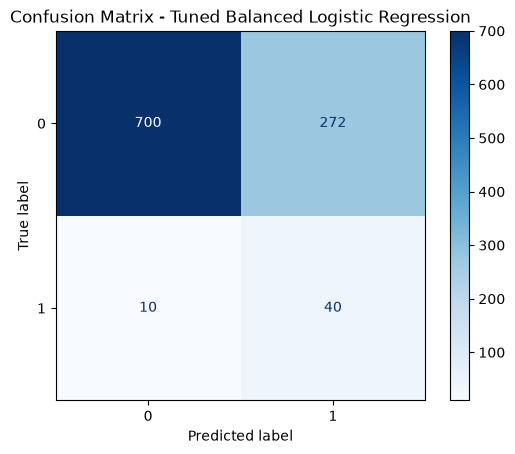


Tuned XGBoost
      Metric  Score
0   Accuracy  0.656
1  Precision  0.109
2     Recall  0.840
3   F1-score  0.193
4    ROC-AUC  0.843

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.65      0.78       972
           1       0.11      0.84      0.19        50

    accuracy                           0.66      1022
   macro avg       0.55      0.74      0.49      1022
weighted avg       0.94      0.66      0.75      1022



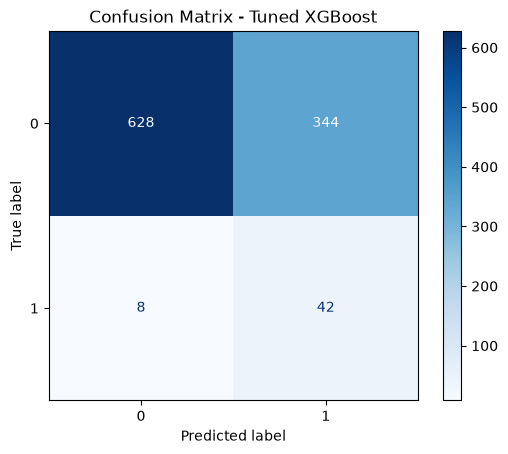

In [30]:
refined_results = {}

refined_results["Balanced Logistic Regression"] = evaluate_model(
    best_lr,
    X_test,
    y_test,
    model_name="Tuned Balanced Logistic Regression",
    plot_cm=True
)

refined_results["XGBoost"] = evaluate_model(
    best_xgb,
    X_test,
    y_test,
    model_name="Tuned XGBoost",
    plot_cm=True
)

In [31]:
refined_comparison = []

for name, result in refined_results.items():

    scores = result["metrics"].set_index(
        "Metric"
    )["Score"]

    refined_comparison.append({
        "Model": name,
        "Accuracy": scores["Accuracy"],
        "Precision": scores["Precision"],
        "Recall": scores["Recall"],
        "F1-score": scores["F1-score"],
        "ROC-AUC": scores["ROC-AUC"]
    })

refined_comparison_df = pd.DataFrame(
    refined_comparison
)

refined_comparison_df.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Balanced Logistic Regression,0.724,0.128,0.80,0.221,0.839
1,XGBoost,0.656,0.109,0.84,0.193,0.843


<Figure size 800x600 with 0 Axes>

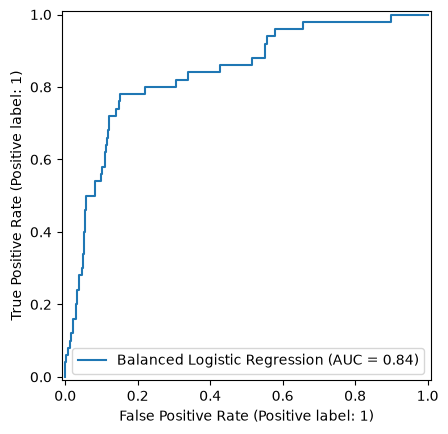

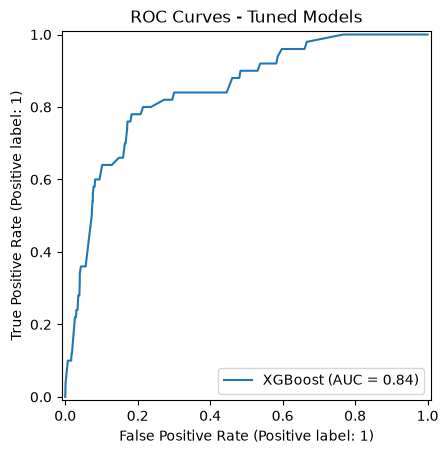

In [32]:
plt.figure(figsize=(8, 6))

for name, result in refined_results.items():

    RocCurveDisplay.from_predictions(
        y_test,
        result["y_prob"],
        name=name
    )

plt.title("ROC Curves - Tuned Models")
plt.show()

<Figure size 800x600 with 0 Axes>

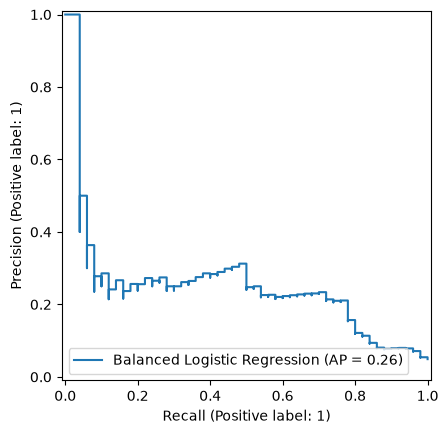

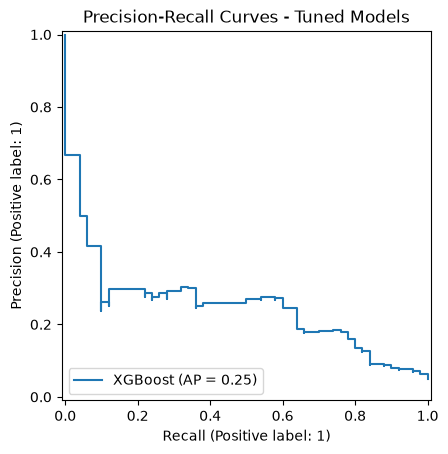

In [33]:
plt.figure(figsize=(8, 6))

for name, result in refined_results.items():

    PrecisionRecallDisplay.from_predictions(
        y_test,
        result["y_prob"],
        name=name
    )

plt.title("Precision-Recall Curves - Tuned Models")
plt.show()

XGBoost has slightly better discrimination, but the improvement is very small. Balanced Logistic Regression achieves better precision and F1-score while maintaining high recall.

### Tuned Model Comparison

After hyperparameter tuning using stratified cross-validation, the
Balanced Logistic Regression and XGBoost models achieved similar
ROC-AUC values (0.839 and 0.843, respectively).

XGBoost achieved slightly higher recall (0.84 vs. 0.80) and ROC-AUC
(0.843 vs. 0.839), indicating slightly better discrimination and
sensitivity to stroke cases.

However, Balanced Logistic Regression achieved higher precision
(0.128 vs. 0.109) and a higher F1-score (0.221 vs. 0.193),
representing a better balance between identifying stroke cases and
limiting false-positive predictions.

Given the small difference in ROC-AUC and the higher F1-score and
precision, Balanced Logistic Regression was selected as the preferred
candidate model for subsequent threshold optimization.

Because the stroke outcome is highly imbalanced, accuracy was not
used as the primary criterion for model selection.

In [35]:
import os
import joblib

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Get the best tuned model
best_lr = lr_grid.best_estimator_

# Save the model
joblib.dump(
    best_lr,
    "../models/balanced_logistic_regression_final.joblib"
)

['../models/balanced_logistic_regression_final.joblib']